# Arabic Handwritten Characters Classifier Evaluation

In [1]:
import pandas as pd

test_labels = pd.read_csv('data/labels/test.csv', header=None) - 1

test_labels.head()

,0
0,0
1,0
2,1
3,1
4,2


In [2]:
import tensorflow as tf

tf.random.set_seed(42)

test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/test',
    labels=test_labels[0].values.tolist(),
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    shuffle=False,
    verbose=True
)

Found 3360 files belonging to 28 classes.


In [3]:
model_1 = tf.keras.models.load_model('model_from_scratch.keras')
model_2 = tf.keras.models.load_model('model_data_aug.keras')

c:\Users\Seif Adin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
import numpy as np

predictions_1 = np.argmax(model_1.predict(test_ds), axis=1)

predictions_1

105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step


array([ 0,  0,  1, ..., 26, 27, 27], shape=(3360,))

In [5]:
predictions_2 = np.argmax(model_2.predict(test_ds), axis=1)

predictions_2

105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step


array([ 0,  0,  1, ..., 26, 27, 27], shape=(3360,))

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(test_labels, predictions_1), accuracy_score(test_labels, predictions_2)

(0.9184523809523809, 0.9383928571428571)

In [7]:
class_names = ['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']

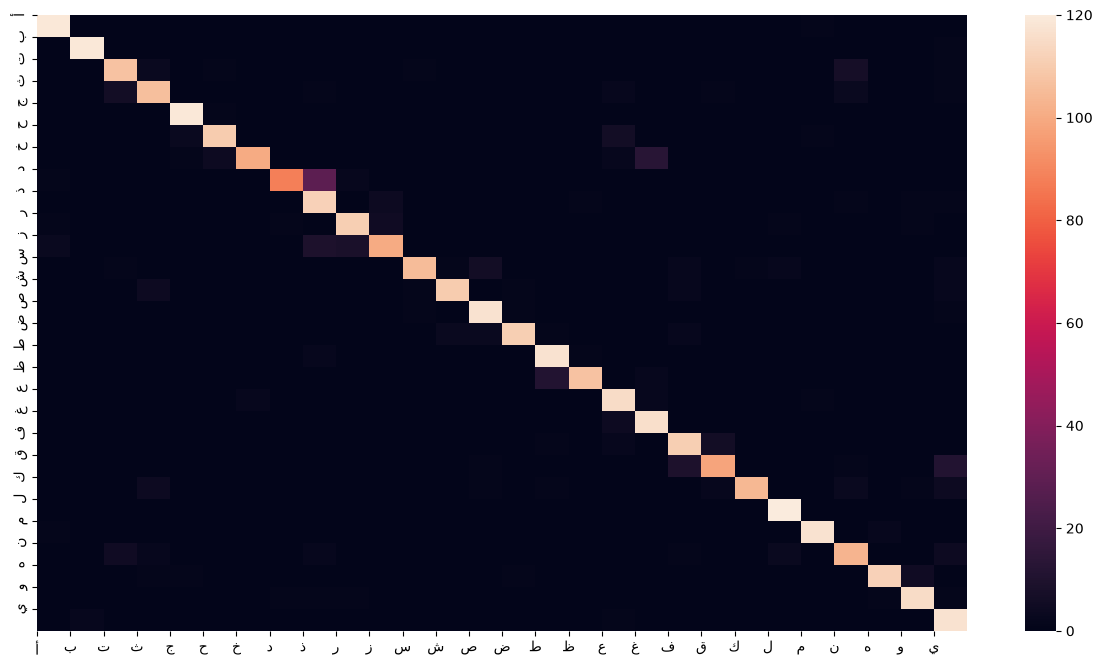

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.heatmap(confusion_matrix(test_labels, predictions_1))
plt.xticks(range(0, 28), class_names)
plt.yticks(range(0, 28), class_names)
plt.show()

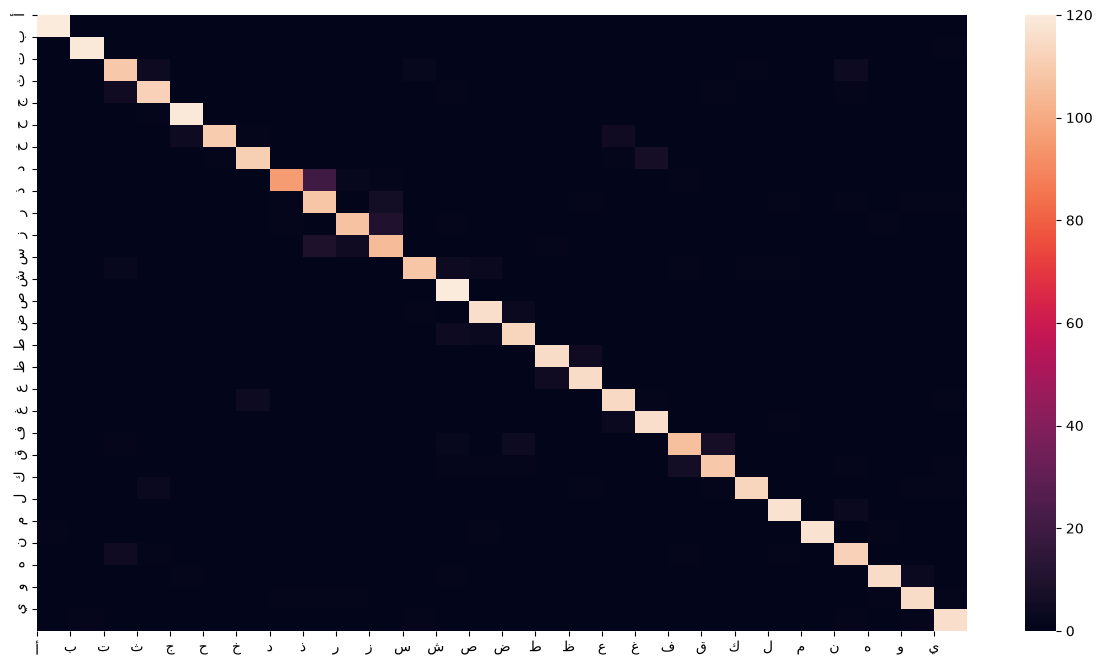

In [9]:
plt.figure(figsize=(15,8))
sns.heatmap(confusion_matrix(test_labels, predictions_2))
plt.xticks(range(0, 28), class_names)
plt.yticks(range(0, 28), class_names)
plt.show()